# Review Analysis with Routing

**Pattern**: Route based on sentiment, with additional diagnosis for negative reviews.

**Workflow**:
```
                              ┌→ [Positive Handler] ────────────┐
START → [Sentiment Classifier] →                                 → [Reply Generator] → END
                              └→ [Negative Diagnosis] → [Extract Details] ─┘
```

**Flow**:
1. User provides a review
2. Classify sentiment: positive or negative
3. If **positive** → simple thank you response
4. If **negative** → diagnose (extract tone, urgency, reason) → then reply

## Setup

In [1]:
from typing import TypedDict, Literal

from langgraph.graph import StateGraph, START, END

## Define State

In [2]:
class ReviewState(TypedDict):
    # Input
    customer_name: str
    review: str
    
    # After classification
    sentiment: str          # positive, negative
    confidence: float
    
    # After diagnosis (only for negative reviews)
    tone: str               # angry, frustrated, disappointed, sad
    urgency: str            # high, medium, low
    reason: str             # extracted reason for complaint
    key_issues: list[str]   # list of specific issues mentioned
    
    # Final output
    reply: str

## Keywords for Analysis

In [3]:
# Sentiment keywords
POSITIVE_KEYWORDS = ["love", "great", "amazing", "excellent", "fantastic", "awesome", 
                     "good", "best", "happy", "satisfied", "recommend", "perfect", 
                     "thank", "wonderful", "impressive"]

NEGATIVE_KEYWORDS = ["bad", "terrible", "worst", "hate", "awful", "horrible", 
                     "disappointed", "waste", "poor", "never", "angry", "frustrated",
                     "broken", "useless", "scam", "refund", "complaint"]

# Tone keywords
ANGRY_KEYWORDS = ["angry", "furious", "outraged", "unacceptable", "disgusted", "worst ever", "scam"]
FRUSTRATED_KEYWORDS = ["frustrated", "annoyed", "irritated", "tried everything", "still not", "keeps"]
DISAPPOINTED_KEYWORDS = ["disappointed", "expected", "letdown", "not what", "thought"]
SAD_KEYWORDS = ["sad", "unfortunate", "wish", "hoped", "really wanted"]

# Urgency keywords
HIGH_URGENCY = ["immediately", "urgent", "asap", "right now", "emergency", "lawsuit", "lawyer"]
MEDIUM_URGENCY = ["soon", "quickly", "waiting", "days", "when will"]

# Issue categories
ISSUE_KEYWORDS = {
    "product_quality": ["broken", "defective", "damaged", "doesn't work", "stopped working", "poor quality"],
    "delivery": ["late", "delayed", "never arrived", "wrong address", "shipping", "delivery"],
    "customer_service": ["rude", "unhelpful", "no response", "ignored", "hung up", "waiting"],
    "pricing": ["overpriced", "expensive", "charged twice", "hidden fees", "refund"],
    "false_advertising": ["not as described", "false", "misleading", "fake", "scam", "lied"]
}

## Node 1: Sentiment Classifier

In [4]:
def classify_sentiment(state: ReviewState) -> dict:
    """Classify review as positive or negative."""
    review = state["review"].lower()
    
    # Count matches
    positive_score = sum(1 for kw in POSITIVE_KEYWORDS if kw in review)
    negative_score = sum(1 for kw in NEGATIVE_KEYWORDS if kw in review)
    
    # Determine sentiment
    if negative_score > positive_score:
        sentiment = "negative"
        confidence = min(negative_score * 0.2, 1.0)
    elif positive_score > negative_score:
        sentiment = "positive"
        confidence = min(positive_score * 0.2, 1.0)
    else:
        # If tied or no keywords, check for negative patterns
        if any(word in review for word in ["but", "however", "although"]):
            sentiment = "negative"
            confidence = 0.4
        else:
            sentiment = "positive"
            confidence = 0.3
    
    return {
        "sentiment": sentiment,
        "confidence": confidence
    }

## Node 2a: Positive Handler (Simple Path)

In [5]:
def positive_handler(state: ReviewState) -> dict:
    """Handle positive reviews - simple thank you."""
    return {
        "tone": "happy",
        "urgency": "low",
        "reason": "Customer is satisfied",
        "key_issues": []
    }

## Node 2b: Negative Diagnosis (Extract Tone, Urgency, Reason)

In [6]:
def diagnose_negative(state: ReviewState) -> dict:
    """Diagnose negative review - extract tone, urgency, reason, and issues."""
    review = state["review"].lower()
    
    # Detect tone
    if any(kw in review for kw in ANGRY_KEYWORDS):
        tone = "angry"
    elif any(kw in review for kw in FRUSTRATED_KEYWORDS):
        tone = "frustrated"
    elif any(kw in review for kw in DISAPPOINTED_KEYWORDS):
        tone = "disappointed"
    elif any(kw in review for kw in SAD_KEYWORDS):
        tone = "sad"
    else:
        tone = "neutral-negative"
    
    # Detect urgency
    if any(kw in review for kw in HIGH_URGENCY):
        urgency = "high"
    elif any(kw in review for kw in MEDIUM_URGENCY):
        urgency = "medium"
    else:
        urgency = "low"
    
    # Extract key issues
    key_issues = []
    for issue_type, keywords in ISSUE_KEYWORDS.items():
        if any(kw in review for kw in keywords):
            key_issues.append(issue_type.replace("_", " ").title())
    
    if not key_issues:
        key_issues = ["General Dissatisfaction"]
    
    # Extract reason (simplified - in production use LLM)
    reason = f"Customer expressed {tone} feelings about: {', '.join(key_issues)}"
    
    return {
        "tone": tone,
        "urgency": urgency,
        "reason": reason,
        "key_issues": key_issues
    }

## Node 3: Reply Generator

In [7]:
def generate_reply(state: ReviewState) -> dict:
    """Generate appropriate reply based on sentiment and diagnosis."""
    
    lines = []
    lines.append("=" * 60)
    lines.append("              REVIEW ANALYSIS & RESPONSE")
    lines.append("=" * 60)
    
    # Original review
    lines.append(f"\n[USER] Customer: {state['customer_name']}")
    lines.append(f"\n[REVIEW] Review: \"{state['review']}\"")
    
    # Analysis
    lines.append("\n" + "-" * 60)
    lines.append("ANALYSIS")
    lines.append("-" * 60)
    
    sentiment_emoji = "" if state["sentiment"] == "positive" else ""
    lines.append(f"  Sentiment: {state['sentiment'].upper()} {sentiment_emoji}")
    lines.append(f"  Confidence: {state['confidence']*100:.0f}%")
    
    if state["sentiment"] == "negative":
        tone_emoji = {"angry": "", "frustrated": "", "disappointed": "", "sad": ""}.get(state["tone"], "")
        lines.append(f"  Tone: {state['tone'].upper()} {tone_emoji}")
        
        urgency_emoji = {"high": "", "medium": "", "low": ""}.get(state["urgency"], "")
        lines.append(f"  Urgency: {state['urgency'].upper()} {urgency_emoji}")
        
        lines.append(f"  Reason: {state['reason']}")
        lines.append(f"  Issues: {', '.join(state['key_issues'])}")
    
    # Generate reply
    lines.append("\n" + "-" * 60)
    lines.append("GENERATED REPLY")
    lines.append("-" * 60)
    
    if state["sentiment"] == "positive":
        reply = f"""Dear {state['customer_name']},

Thank you so much for your wonderful review! 

We're thrilled to hear about your positive experience. Your feedback means 
the world to us and motivates our team to keep delivering excellence.

We look forward to serving you again!

Warm regards,
Customer Success Team"""
    else:
        # Customize based on tone and urgency
        if state["urgency"] == "high":
            urgency_line = "We are treating this as a TOP PRIORITY and will respond within 2 hours."
        elif state["urgency"] == "medium":
            urgency_line = "We will address this within 24 hours."
        else:
            urgency_line = "Our team will review and respond soon."
        
        if state["tone"] == "angry":
            empathy = "We completely understand your frustration, and we sincerely apologize."
        elif state["tone"] == "frustrated":
            empathy = "We're truly sorry for the inconvenience you've experienced."
        elif state["tone"] == "disappointed":
            empathy = "We're sorry we didn't meet your expectations."
        else:
            empathy = "We apologize for any trouble this has caused."
        
        issues_text = ", ".join(state["key_issues"]).lower()
        
        reply = f"""Dear {state['customer_name']},

{empathy}

We take your feedback about {issues_text} very seriously. {urgency_line}

Here's what we're doing:
  • Your case has been escalated to our senior team
  • A dedicated support agent will contact you directly
  • We're investigating the root cause to prevent this in the future

As a gesture of goodwill, we'd like to offer you a 20% discount on your 
next purchase.

Please reply to this message or call us at 1800-XXX-XXXX.

Sincerely,
Customer Resolution Team"""
    
    lines.append(f"\n{reply}")
    lines.append("\n" + "=" * 60)
    
    return {"reply": "\n".join(lines)}

## Routing Function

In [8]:
def route_by_sentiment(state: ReviewState) -> Literal["positive", "negative"]:
    """Route to appropriate handler based on sentiment."""
    if state["sentiment"] == "positive":
        return "positive"
    else:
        return "negative"

## Build the Graph

In [9]:
# Create graph
graph = StateGraph(ReviewState)

# Add nodes
graph.add_node("classifier", classify_sentiment)
graph.add_node("positive_handler", positive_handler)
graph.add_node("diagnose_negative", diagnose_negative)
graph.add_node("generate_reply", generate_reply)

# Add edges
graph.add_edge(START, "classifier")

# CONDITIONAL EDGE: Route based on sentiment
graph.add_conditional_edges(
    "classifier",
    route_by_sentiment,
    {
        "positive": "positive_handler",
        "negative": "diagnose_negative"
    }
)

# Both paths lead to reply generator
graph.add_edge("positive_handler", "generate_reply")
graph.add_edge("diagnose_negative", "generate_reply")

graph.add_edge("generate_reply", END)

# Compile
app = graph.compile()

## Visualize the Graph

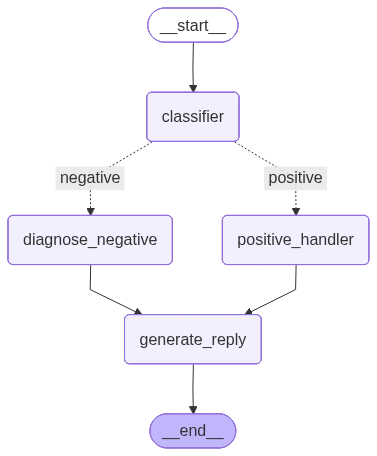

In [10]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## Test Case 1: Positive Review

In [11]:
result = app.invoke({
    "customer_name": "Rahul Sharma",
    "review": "Absolutely love this product! Amazing quality and fast delivery. Best purchase ever!"
})

print(result["reply"])

              REVIEW ANALYSIS & RESPONSE

[USER] Customer: Rahul Sharma

[REVIEW] Review: "Absolutely love this product! Amazing quality and fast delivery. Best purchase ever!"

------------------------------------------------------------
ANALYSIS
------------------------------------------------------------
  Sentiment: POSITIVE 
  Confidence: 60%

------------------------------------------------------------
GENERATED REPLY
------------------------------------------------------------

Dear Rahul Sharma,

Thank you so much for your wonderful review! 

We're thrilled to hear about your positive experience. Your feedback means 
the world to us and motivates our team to keep delivering excellence.

We look forward to serving you again!

Warm regards,
Customer Success Team



## Test Case 2: Negative Review - Angry Customer (High Urgency)

In [12]:
result = app.invoke({
    "customer_name": "Priya Patel",
    "review": "This is unacceptable! The product arrived broken and customer service hung up on me. I want a refund immediately or I'm calling my lawyer!"
})

print(result["reply"])

              REVIEW ANALYSIS & RESPONSE

[USER] Customer: Priya Patel

[REVIEW] Review: "This is unacceptable! The product arrived broken and customer service hung up on me. I want a refund immediately or I'm calling my lawyer!"

------------------------------------------------------------
ANALYSIS
------------------------------------------------------------
  Sentiment: NEGATIVE 
  Confidence: 40%
  Tone: ANGRY 
  Urgency: HIGH 
  Reason: Customer expressed angry feelings about: Product Quality, Customer Service, Pricing
  Issues: Product Quality, Customer Service, Pricing

------------------------------------------------------------
GENERATED REPLY
------------------------------------------------------------

Dear Priya Patel,

We completely understand your frustration, and we sincerely apologize.

We take your feedback about product quality, customer service, pricing very seriously. We are treating this as a TOP PRIORITY and will respond within 2 hours.

Here's what we're doing:
  

## Test Case 3: Negative Review - Frustrated Customer

In [13]:
result = app.invoke({
    "customer_name": "Amit Kumar",
    "review": "I'm so frustrated! I've tried everything but the app keeps crashing. Been waiting for support for 3 days now."
})

print(result["reply"])

              REVIEW ANALYSIS & RESPONSE

[USER] Customer: Amit Kumar

[REVIEW] Review: "I'm so frustrated! I've tried everything but the app keeps crashing. Been waiting for support for 3 days now."

------------------------------------------------------------
ANALYSIS
------------------------------------------------------------
  Sentiment: NEGATIVE 
  Confidence: 20%
  Tone: FRUSTRATED 
  Urgency: MEDIUM 
  Reason: Customer expressed frustrated feelings about: Customer Service
  Issues: Customer Service

------------------------------------------------------------
GENERATED REPLY
------------------------------------------------------------

Dear Amit Kumar,

We're truly sorry for the inconvenience you've experienced.

We take your feedback about customer service very seriously. We will address this within 24 hours.

Here's what we're doing:
  • Your case has been escalated to our senior team
  • A dedicated support agent will contact you directly
  • We're investigating the root cau

## Test Case 4: Negative Review - Disappointed Customer

In [14]:
result = app.invoke({
    "customer_name": "Sneha Reddy",
    "review": "Really disappointed with this purchase. Expected much better quality based on the description. Not what I thought it would be."
})

print(result["reply"])

              REVIEW ANALYSIS & RESPONSE

[USER] Customer: Sneha Reddy

[REVIEW] Review: "Really disappointed with this purchase. Expected much better quality based on the description. Not what I thought it would be."

------------------------------------------------------------
ANALYSIS
------------------------------------------------------------
  Sentiment: NEGATIVE 
  Confidence: 20%
  Tone: DISAPPOINTED 
  Urgency: LOW 
  Reason: Customer expressed disappointed feelings about: General Dissatisfaction
  Issues: General Dissatisfaction

------------------------------------------------------------
GENERATED REPLY
------------------------------------------------------------

Dear Sneha Reddy,

We're sorry we didn't meet your expectations.

We take your feedback about general dissatisfaction very seriously. Our team will review and respond soon.

Here's what we're doing:
  • Your case has been escalated to our senior team
  • A dedicated support agent will contact you directly
  • We'r

## Test Case 5: Negative Review - Delivery Issue

In [15]:
result = app.invoke({
    "customer_name": "Vikram Singh",
    "review": "Terrible service! My order was delayed by 2 weeks and when it finally arrived, it was sent to the wrong address. Very poor experience."
})

print(result["reply"])

              REVIEW ANALYSIS & RESPONSE

[USER] Customer: Vikram Singh

[REVIEW] Review: "Terrible service! My order was delayed by 2 weeks and when it finally arrived, it was sent to the wrong address. Very poor experience."

------------------------------------------------------------
ANALYSIS
------------------------------------------------------------
  Sentiment: NEGATIVE 
  Confidence: 40%
  Tone: NEUTRAL-NEGATIVE 
  Urgency: LOW 
  Reason: Customer expressed neutral-negative feelings about: Delivery
  Issues: Delivery

------------------------------------------------------------
GENERATED REPLY
------------------------------------------------------------

Dear Vikram Singh,

We apologize for any trouble this has caused.

We take your feedback about delivery very seriously. Our team will review and respond soon.

Here's what we're doing:
  • Your case has been escalated to our senior team
  • A dedicated support agent will contact you directly
  • We're investigating the root ca

## Test Case 6: Mixed Review (Leaning Negative)

In [16]:
result = app.invoke({
    "customer_name": "Ananya Gupta",
    "review": "The product looks good, but it stopped working after just 2 days. Waste of money."
})

print(result["reply"])

              REVIEW ANALYSIS & RESPONSE

[USER] Customer: Ananya Gupta

[REVIEW] Review: "The product looks good, but it stopped working after just 2 days. Waste of money."

------------------------------------------------------------
ANALYSIS
------------------------------------------------------------
  Sentiment: NEGATIVE 
  Confidence: 40%
  Tone: NEUTRAL-NEGATIVE 
  Urgency: MEDIUM 
  Reason: Customer expressed neutral-negative feelings about: Product Quality
  Issues: Product Quality

------------------------------------------------------------
GENERATED REPLY
------------------------------------------------------------

Dear Ananya Gupta,

We apologize for any trouble this has caused.

We take your feedback about product quality very seriously. We will address this within 24 hours.

Here's what we're doing:
  • Your case has been escalated to our senior team
  • A dedicated support agent will contact you directly
  • We're investigating the root cause to prevent this in the fut

## Stream Execution (See the Path)

In [17]:
print("=" * 60)
print("STREAMING EXECUTION")
print("=" * 60)

for step in app.stream({
    "customer_name": "Test User", 
    "review": "Horrible product! Overpriced and doesn't work. I want my money back now!"
}):
    for node_name, output in step.items():
        print(f"\n[DONE] Node: {node_name}")
        
        if node_name == "classifier":
            print(f"   Sentiment: {output['sentiment']} ({output['confidence']*100:.0f}%)")
            print(f"   → Routing to: {'positive_handler' if output['sentiment'] == 'positive' else 'diagnose_negative'}")
        
        elif node_name == "diagnose_negative":
            print(f"   Tone: {output['tone']}")
            print(f"   Urgency: {output['urgency']}")
            print(f"   Issues: {output['key_issues']}")
        
        elif node_name == "positive_handler":
            print("   → Simple positive flow (no diagnosis needed)")

STREAMING EXECUTION

[DONE] Node: classifier
   Sentiment: negative (20%)
   → Routing to: diagnose_negative

[DONE] Node: diagnose_negative
   Tone: neutral-negative
   Urgency: low
   Issues: ['Product Quality', 'Pricing']

[DONE] Node: generate_reply


## Interactive: Try Your Own Review

In [18]:
# Change these!
my_name = "Your Name"
my_review = "Write your review here..."

result = app.invoke({
    "customer_name": my_name,
    "review": my_review
})

print(result["reply"])

              REVIEW ANALYSIS & RESPONSE

[USER] Customer: Your Name

[REVIEW] Review: "Write your review here..."

------------------------------------------------------------
ANALYSIS
------------------------------------------------------------
  Sentiment: POSITIVE 
  Confidence: 30%

------------------------------------------------------------
GENERATED REPLY
------------------------------------------------------------

Dear Your Name,

Thank you so much for your wonderful review! 

We're thrilled to hear about your positive experience. Your feedback means 
the world to us and motivates our team to keep delivering excellence.

We look forward to serving you again!

Warm regards,
Customer Success Team



## Key Takeaways

1. **Conditional routing** selects different paths based on classification result
2. **Negative path has more nodes** (diagnosis step) than positive path
3. **Both paths converge** to the same reply generator
4. **Diagnosis extracts**: tone (angry/frustrated/disappointed), urgency (high/medium/low), and specific issues
5. **Reply is customized** based on all extracted information

### Pattern:
```
Classifier → [Route] → Simple Path (positive)
                    → Complex Path (negative) → Additional Processing
                    → Both paths merge at final node
```